In [3]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import time

import spacy

from wordcloud import WordCloud
import matplotlib.pyplot as plt

import pandas as pd

from collections import Counter
import seaborn as sns
from konlpy.tag import Okt
from transformers import pipeline
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer



In [4]:
# 1. 크롬 브라우저 열기 (자동으로 꺼지지 않게 옵션 설정)
options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")  # 브라우저 최대화
driver = webdriver.Chrome(options=options)

In [5]:
# 2. 유튜브 접속
driver.get("https://www.youtube.com/")
time.sleep(2)

In [6]:
# 3. 검색창에 검색어 입력
search_box = driver.find_element(By.NAME, "search_query")
search_box.send_keys("SOUTH KOREA IS OVER")
search_box.send_keys(Keys.RETURN)
time.sleep(2)

In [7]:
# 4. 첫 번째 동영상 정보 가져오기
first_video = driver.find_element(By.ID, "video-title")
title = first_video.get_attribute("title")
url = first_video.get_attribute("href")

print("🎬 제목:", title)
print("🔗 링크:", url)

first_video.click()
time.sleep(3)

🎬 제목: SOUTH KOREA IS OVER
🔗 링크: https://www.youtube.com/watch?v=Ufmu1WD2TSk&pp=ygUTU09VVEggS09SRUEgSVMgT1ZFUg%3D%3D


In [8]:
# 5. 댓글 영역까지 스크롤 내리기
driver.execute_script("window.scrollTo(0, 800);")
time.sleep(2)
driver.execute_script("window.scrollTo(0, 1500);")
time.sleep(3)

In [9]:
#6. 여러 댓글 가져오기
comments = driver.find_elements(By.XPATH, '//*[@id="content-text"]')

# 각 댓글 텍스트 출력
for idx, comment in enumerate(comments[:10]):  # 상위 10개만 예시
    print(f"💬 댓글 {idx+1}: {comment.text}")

💬 댓글 1: Do you have a balanced news diet? Go to https://ground.news/KiN to see reporting from a variety of sources and perspectives around the world. 
Subscribe for 40% off their unlimited access Vantage plan through our link.
💬 댓글 2: I’m Korean, born and raised in this country, and after watching this video, I just sat in silence for a while. Not because it shocked me, but because it said out loud what so many of us already feel deep inside: that it’s too late. There’s no fixing this anymore.

I’m in my early 30s now, living in Seoul, working a job that consumes most of my time and energy. I went to a good university, did everything “right” according to our society’s standards, but I feel like I’m running on empty. Every day feels like survival, not life.

Korea’s government throws money at us — baby bonuses, housing incentives, free childcare. But it all feels like putting a tiny bandage on a broken system. No amount of money can fix the reality we live in. The pressure to succeed st

In [10]:
for i in range(50):  # 50번 스크롤 및 3,000개 수집
    driver.execute_script("window.scrollBy(0, 3000);")
    time.sleep(2)


In [11]:
comments = driver.find_elements(By.ID, "content-text")
likes = driver.find_elements(By.ID, "vote-count-middle")

data = []
for c, l in zip(comments, likes):
    text = c.text.strip()
    try:
        like = int(l.text.strip().replace("천", "000").replace("만", "0000")) if l.text.strip() else 0
    except:
        like = 0
    data.append((text, like))


In [12]:
# 좋아요 기준 내림차순 정렬
sorted_data = sorted(data, key=lambda x: x[1], reverse=True)
top_3000_comments = [text for text, like in sorted_data[:3000]]


In [13]:
nlp = spacy.load("en_core_web_sm")  # 영어 모델 로딩

def extract_nouns_spacy(text):
    doc = nlp(text)
    return [token.text.lower() for token in doc if token.pos_ == "NOUN"]


In [14]:
all_nouns = []
for comment in top_3000_comments:
    all_nouns += extract_nouns_spacy(comment)

noun_text = " ".join(all_nouns)

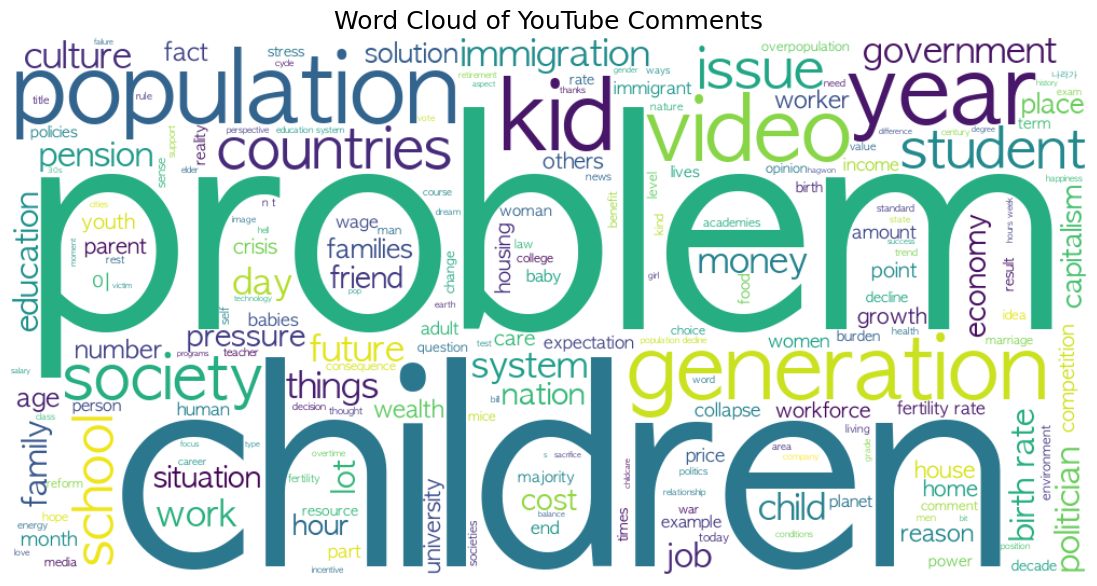

In [ ]:
custom_stopwords = {
    'korea', 'south', 'people', 'country',
    'thing', 'time', 'way', 'life', 'world', 'one',
    'someone', 'nothing', 'everything', 'anything'
}

wc = WordCloud(
    font_path="/Library/Fonts/AppleGothic.ttf",
    background_color="white",
    width=1000,
    height=500,
    stopwords=custom_stopwords
).generate(noun_text)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of YouTube Comments", fontsize=18)
plt.show()


In [16]:
# 댓글만 담긴 DataFrame 만들기
df = pd.DataFrame({'comment': top_3000_comments})

# CSV로 저장 (utf-8 인코딩)
df.to_csv("top3000_comments.csv", index=False, encoding='utf-8')


In [17]:
with open("top3000_comments.txt", "w", encoding='utf-8') as f:
    for comment in top_3000_comments:
        f.write(comment + "\n")

In [18]:
# 명사만 따로 추출
df_nouns = pd.DataFrame({'noun': all_nouns})
df_nouns.to_csv("list_top3000_comment_nouns.csv", index=False, encoding='utf-8')


In [19]:
with open("list_top3000_comment_nouns.txt", "w", encoding='utf-8') as f:
    for noun in all_nouns:
        f.write(noun + "\n")


In [20]:
#빈도

noun_freq = Counter(all_nouns)
df_freq = pd.DataFrame(noun_freq.most_common(), columns=["noun", "frequency"])
df_freq.to_csv("top3000_comment_nouns_freq.csv", index=False, encoding='utf-8')


In [21]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd

analyzer = SentimentIntensityAnalyzer()

# top_3000_comments 리스트가 필요함
results = []
for comment in top_3000_comments:
    scores = analyzer.polarity_scores(comment)
    compound = scores['compound']
    sentiment = "positive" if compound > 0.05 else "negative" if compound < -0.05 else "neutral"
    scores['text'] = comment
    scores['sentiment'] = sentiment
    results.append(scores)

df_sentiment = pd.DataFrame(results)


/var/folders/rq/j2w10g4d5lq4ltknpfxh_gv80000gn/T/ipykernel_1383/129032886.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sentiment, x="sentiment", palette="pastel")


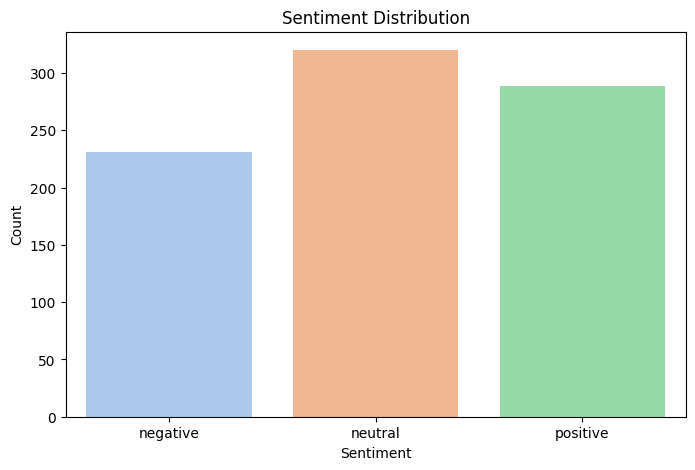

In [22]:
# 감정분석

plt.figure(figsize=(8, 5))
sns.countplot(data=df_sentiment, x="sentiment", palette="pastel")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [23]:
df_sentiment[df_sentiment['sentiment'] == 'positive'].to_csv("positive_comments.csv", index=False)
df_sentiment[df_sentiment['sentiment'] == 'negative'].to_csv("negative_comments.csv", index=False)

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# 댓글 리스트 불러오기
texts = top_3000_comments  # 이미 전처리된 텍스트 리스트

# TF-IDF 벡터화
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.9, min_df=10)
X = vectorizer.fit_transform(texts)

# NMF로 주제 추출
nmf = NMF(n_components=5, random_state=42)
nmf.fit(X)

NMF(n_components=5, random_state=42)

In [25]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd

analyzer = SentimentIntensityAnalyzer()

sentiment_results = []
for comment in top_3000_comments:
    score = analyzer.polarity_scores(comment)
    compound = score['compound']
    if compound >= 0.05:
        sentiment = 'positive'
    elif compound <= -0.05:
        sentiment = 'negative'
    else:
        sentiment = 'neutral'
    sentiment_results.append({'text': comment, 'compound': compound, 'sentiment': sentiment})

df_sentiment = pd.DataFrame(sentiment_results)


In [26]:
keywords = ['problem', 'children', 'year', 'population', 'generation', 'future', 'birth rate', 'immigration']



📌 Keyword: problem
sentiment
negative    51
positive    29
Name: count, dtype: int64


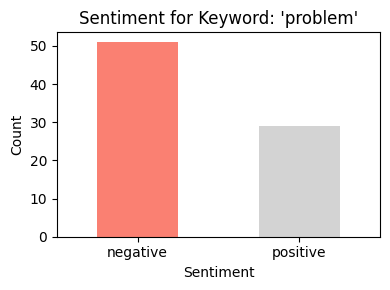


📌 Keyword: children
sentiment
positive    42
negative    29
neutral      6
Name: count, dtype: int64


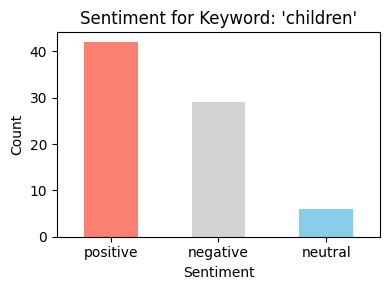


📌 Keyword: year
sentiment
positive    32
negative    27
neutral      6
Name: count, dtype: int64


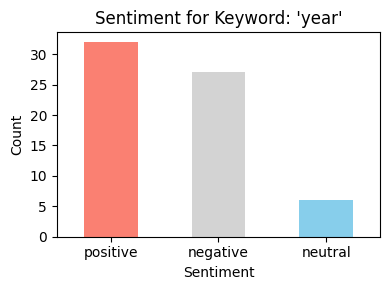


📌 Keyword: population
sentiment
positive    39
negative    34
neutral      6
Name: count, dtype: int64


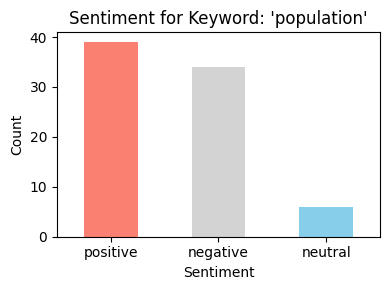


📌 Keyword: generation
sentiment
negative    27
positive    19
neutral      2
Name: count, dtype: int64


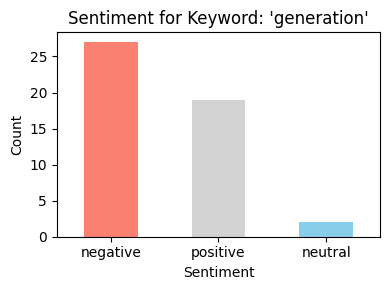


📌 Keyword: future
sentiment
negative    22
positive    19
neutral      5
Name: count, dtype: int64


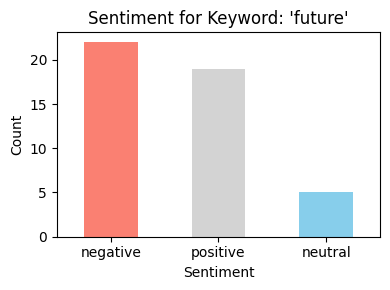


📌 Keyword: birth rate
sentiment
negative    16
positive    13
neutral      1
Name: count, dtype: int64


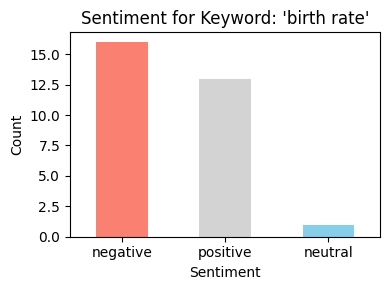


📌 Keyword: immigration
sentiment
positive    19
negative    14
neutral      4
Name: count, dtype: int64


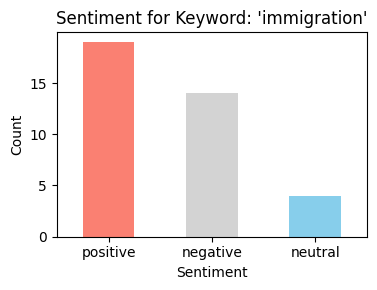

In [27]:
from collections import Counter
import matplotlib.pyplot as plt

for keyword in keywords:
    keyword_df = df_sentiment[df_sentiment['text'].str.lower().str.contains(keyword)]
    counts = keyword_df['sentiment'].value_counts()
    
    print(f"\n📌 Keyword: {keyword}")
    print(counts)

    # 시각화
    plt.figure(figsize=(4,3))
    counts.plot(kind='bar', color=['salmon', 'lightgray', 'skyblue'])
    plt.title(f"Sentiment for Keyword: '{keyword}'")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
